<cell_type>markdown</cell_type> # Part B — Notebook 3: Feature Ablation Study
#
# **Research**: Beyond Gut Feel — AI vs Developer Intuition in Observability Decisions
#
# **Goal**: Determine whether the classifier learns code structure or just
# reads error-words in the log message. Ablate feature groups and compare.
#
# **Figure produced**:
# - `fig09_ablation_bar.png` — CV + cross-project ablation side-by-side
#
# **Input**: `data/log_level_dataset.csv` (from notebook 01)
#
# **Run time**: ~5 minutes
#
# ---

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report
import scipy.sparse as sp
import warnings
warnings.filterwarnings('ignore')

# === Google Drive mount (persists data across notebooks) ===
try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_DIR = '/content/drive/MyDrive/beyond-gut-feel'
except ImportError:
    BASE_DIR = os.path.join(os.path.dirname(os.path.abspath('.')), '..')

FIGURE_DIR = os.path.join(BASE_DIR, 'figures')
DATA_DIR = os.path.join(BASE_DIR, 'data')
os.makedirs(FIGURE_DIR, exist_ok=True)

# Publication style
plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 11,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

np.random.seed(42)

print(f'Figures → {os.path.abspath(FIGURE_DIR)}')
print(f'Data   → {os.path.abspath(DATA_DIR)}')
print('Libraries loaded!')

Mounted at /content/drive
Figures → /content/drive/MyDrive/beyond-gut-feel/figures
Data   → /content/drive/MyDrive/beyond-gut-feel/data
Libraries loaded!


In [2]:
# Load and clean dataset (same as notebook 02)
df = pd.read_csv(os.path.join(DATA_DIR, 'log_level_dataset.csv'),
                 on_bad_lines='skip', engine='python')

# Filter valid log levels
valid_levels = ['DEBUG', 'INFO', 'WARN', 'ERROR']
before = len(df)
df = df[df['log_level'].isin(valid_levels)].reset_index(drop=True)
after = len(df)
print(f'Rows before filter: {before}, after: {after}, lost: {before - after} ({(before-after)/before*100:.1f}%)')

# Fix boolean columns
bool_cols = ['in_catch', 'in_conditional', 'in_try', 'has_return', 'has_throw']
for col in bool_cols:
    if col in df.columns:
        df[col] = df[col].map({'True': 1, 'False': 0, True: 1, False: 0}).fillna(0).astype(int)

# Fix numeric columns
for col in ['var_count', 'msg_length', 'line_length']:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(float)

print(f'Dataset: {len(df):,} statements from {df["repo"].nunique()} repos')
print(f'Class distribution:')
for level in valid_levels:
    count = len(df[df['log_level'] == level])
    print(f'  {level:6s}: {count:>5,} ({count/len(df)*100:.1f}%)')

Rows before filter: 15822, after: 15652, lost: 170 (1.1%)
Dataset: 15,652 statements from 15 repos
Class distribution:
  DEBUG : 2,154 (13.8%)
  INFO  : 7,027 (44.9%)
  WARN  : 2,076 (13.3%)
  ERROR : 4,395 (28.1%)


In [3]:
# Build all feature groups separately so we can ablate

# 1. Context TF-IDF
context_tfidf = TfidfVectorizer(
    max_features=500, ngram_range=(1, 2),
    stop_words='english', min_df=5, max_df=0.8,
    token_pattern=r'\b[a-zA-Z_][a-zA-Z0-9_]{1,30}\b'
)
X_context = context_tfidf.fit_transform(df['full_context'].fillna(''))

# 2. Message TF-IDF
message_tfidf = TfidfVectorizer(
    max_features=200, ngram_range=(1, 2),
    min_df=3, max_df=0.8,
    token_pattern=r'\b[a-zA-Z_][a-zA-Z0-9_]{1,30}\b'
)
X_message = message_tfidf.fit_transform(df['log_message'].fillna(''))

# 3. Structural features
structural_cols = ['in_catch', 'in_conditional', 'in_try',
                   'has_return', 'has_throw', 'var_count',
                   'msg_length', 'line_length']
X_structural = sp.csr_matrix(df[structural_cols].astype(float).values)

# 4. File type one-hot
X_filetype = sp.csr_matrix(pd.get_dummies(df['file_type'], prefix='ft').values)

# Labels
le = LabelEncoder()
y = le.fit_transform(df['log_level'])
class_names = list(le.classes_)

print(f'Context TF-IDF: {X_context.shape}')
print(f'Message TF-IDF: {X_message.shape}')
print(f'Structural:     {X_structural.shape}')
print(f'File type:      {X_filetype.shape}')
print(f'Classes:        {class_names}')

Context TF-IDF: (15652, 500)
Message TF-IDF: (15652, 200)
Structural:     (15652, 8)
File type:      (15652, 7)
Classes:        ['DEBUG', 'ERROR', 'INFO', 'WARN']


In [4]:
# Define the four ablation conditions
conditions = {
    'Full (all features)': sp.hstack([X_context, X_message, X_structural, X_filetype]),
    'No message TF-IDF': sp.hstack([X_context, X_structural, X_filetype]),
    'Structural + file type only': sp.hstack([X_structural, X_filetype]),
    'Message TF-IDF only': X_message,
    'Context TF-IDF only': X_context,
}

for name, X in conditions.items():
    print(f'{name:30s}: {X.shape[1]:>5} features')

Full (all features)           :   715 features
No message TF-IDF             :   515 features
Structural + file type only   :    15 features
Message TF-IDF only           :   200 features
Context TF-IDF only           :   500 features


## 1. Cross-Validation Ablation

5-fold stratified CV for each condition.

In [5]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_ablation = {}

for cond_name, X_cond in conditions.items():
    print(f'\nRunning: {cond_name} ({X_cond.shape[1]} features)...')
    fold_scores = {'accuracy': [], 'macro_f1': [], 'weighted_f1': []}

    for fold, (train_idx, test_idx) in enumerate(skf.split(X_cond, y)):
        model = XGBClassifier(
            n_estimators=200, max_depth=8,
            learning_rate=0.1, random_state=42,
            eval_metric='mlogloss', n_jobs=-1
        )
        model.fit(X_cond[train_idx], y[train_idx])
        preds = model.predict(X_cond[test_idx])

        fold_scores['accuracy'].append(accuracy_score(y[test_idx], preds))
        fold_scores['macro_f1'].append(f1_score(y[test_idx], preds, average='macro'))
        fold_scores['weighted_f1'].append(f1_score(y[test_idx], preds, average='weighted'))

    cv_ablation[cond_name] = fold_scores
    acc = np.mean(fold_scores['accuracy'])
    mf1 = np.mean(fold_scores['macro_f1'])
    print(f'  Accuracy: {acc:.4f} | Macro F1: {mf1:.4f}')

print('\nDone!')


Running: Full (all features) (715 features)...
  Accuracy: 0.9693 | Macro F1: 0.9647

Running: No message TF-IDF (515 features)...
  Accuracy: 0.9631 | Macro F1: 0.9583

Running: Structural + file type only (15 features)...
  Accuracy: 0.7124 | Macro F1: 0.6344

Running: Message TF-IDF only (200 features)...
  Accuracy: 0.6285 | Macro F1: 0.5037

Running: Context TF-IDF only (500 features)...
  Accuracy: 0.9417 | Macro F1: 0.9364

Done!


In [6]:
# Also run keyword heuristic for comparison
def keyword_heuristic(row):
    context = str(row['full_context']).lower()
    message = str(row['log_message']).lower()

    if row.get('in_catch', False):
        return 'ERROR'
    if row.get('has_throw', False):
        return 'ERROR'

    error_kw = ['error', 'fail', 'exception', 'crash', 'fatal',
                'unable to', 'cannot', 'could not', 'unexpected']
    if any(kw in message for kw in error_kw):
        return 'ERROR'

    warn_kw = ['warn', 'deprecat', 'fallback', 'retry',
               'timeout', 'slow', 'missing', 'not found',
               'skipping', 'ignoring']
    if any(kw in message for kw in warn_kw):
        return 'WARN'

    debug_kw = ['debug', 'trace', 'verbose', 'entering',
                'leaving', 'params:', 'args:', 'query:']
    if any(kw in message for kw in debug_kw):
        return 'DEBUG'

    return 'INFO'

heuristic_preds = le.transform(df.apply(keyword_heuristic, axis=1))
heur_f1 = f1_score(y, heuristic_preds, average='macro')
print(f'Keyword heuristic macro F1: {heur_f1:.4f}')

Keyword heuristic macro F1: 0.3779


In [7]:
# Summary table
print('=' * 75)
print('FEATURE ABLATION — CROSS-VALIDATION RESULTS')
print('=' * 75)
print(f'{"Condition":35s} {"Features":>8s} {"Macro F1":>12s} {"Δ vs Full":>10s}')
print('-' * 75)

full_f1 = np.mean(cv_ablation['Full (all features)']['macro_f1'])

# Add heuristic row
print(f'{"Keyword heuristic (baseline)":35s} {"6 rules":>8s} {heur_f1:>12.4f} {"":>10s}')
print('-' * 75)

for cond_name, scores in cv_ablation.items():
    mf1 = np.mean(scores['macro_f1'])
    std = np.std(scores['macro_f1'])
    n_feat = conditions[cond_name].shape[1]
    delta = mf1 - full_f1
    delta_str = f'{delta:+.4f}' if cond_name != 'Full (all features)' else 'baseline'
    print(f'{cond_name:35s} {n_feat:>8d} {mf1:.4f}±{std:.4f} {delta_str:>10s}')

print('=' * 75)

FEATURE ABLATION — CROSS-VALIDATION RESULTS
Condition                           Features     Macro F1  Δ vs Full
---------------------------------------------------------------------------
Keyword heuristic (baseline)         6 rules       0.3779           
---------------------------------------------------------------------------
Full (all features)                      715 0.9647±0.0015   baseline
No message TF-IDF                        515 0.9583±0.0021    -0.0064
Structural + file type only               15 0.6344±0.0101    -0.3303
Message TF-IDF only                      200 0.5037±0.0070    -0.4610
Context TF-IDF only                      500 0.9364±0.0023    -0.0282


## 2. Cross-Project Ablation

The real test: train on 12 repos, test on 3 unseen repos.
Does the model still work without message features?

In [8]:
# Cross-project split
test_repos = ['strapi', 'immich', 'calcom']
train_repos = [r for r in df['repo'].unique() if r not in test_repos]

train_mask = df['repo'].isin(train_repos)
test_mask = df['repo'].isin(test_repos)

print(f'Train: {train_mask.sum():,} from {len(train_repos)} repos')
print(f'Test:  {test_mask.sum():,} from {len(test_repos)} repos')

# Rebuild TF-IDF fit on train only
ctx_tfidf_cp = TfidfVectorizer(
    max_features=500, ngram_range=(1, 2),
    stop_words='english', min_df=5, max_df=0.8,
    token_pattern=r'\b[a-zA-Z_][a-zA-Z0-9_]{1,30}\b'
)
msg_tfidf_cp = TfidfVectorizer(
    max_features=200, ngram_range=(1, 2),
    min_df=3, max_df=0.8,
    token_pattern=r'\b[a-zA-Z_][a-zA-Z0-9_]{1,30}\b'
)

X_ctx_tr = ctx_tfidf_cp.fit_transform(df.loc[train_mask, 'full_context'].fillna(''))
X_ctx_te = ctx_tfidf_cp.transform(df.loc[test_mask, 'full_context'].fillna(''))

X_msg_tr = msg_tfidf_cp.fit_transform(df.loc[train_mask, 'log_message'].fillna(''))
X_msg_te = msg_tfidf_cp.transform(df.loc[test_mask, 'log_message'].fillna(''))

X_str_tr = sp.csr_matrix(df.loc[train_mask, structural_cols].astype(float).values)
X_str_te = sp.csr_matrix(df.loc[test_mask, structural_cols].astype(float).values)

ft_dummies = pd.get_dummies(df['file_type'], prefix='ft')
X_ft_tr = sp.csr_matrix(ft_dummies.loc[train_mask].values)
X_ft_te = sp.csr_matrix(ft_dummies.loc[test_mask].values)

y_tr = le.transform(df.loc[train_mask, 'log_level'])
y_te = le.transform(df.loc[test_mask, 'log_level'])

# Build ablation conditions for cross-project
cp_conditions = {
    'Full (all features)': (
        sp.hstack([X_ctx_tr, X_msg_tr, X_str_tr, X_ft_tr]),
        sp.hstack([X_ctx_te, X_msg_te, X_str_te, X_ft_te])
    ),
    'No message TF-IDF': (
        sp.hstack([X_ctx_tr, X_str_tr, X_ft_tr]),
        sp.hstack([X_ctx_te, X_str_te, X_ft_te])
    ),
    'Structural + file type only': (
        sp.hstack([X_str_tr, X_ft_tr]),
        sp.hstack([X_str_te, X_ft_te])
    ),
    'Message TF-IDF only': (
        X_msg_tr, X_msg_te
    ),
    'Context TF-IDF only': (
        X_ctx_tr, X_ctx_te
    ),
}

print('\nFeature matrices built.')

Train: 12,197 from 12 repos
Test:  3,455 from 3 repos

Feature matrices built.


In [9]:
# Run cross-project ablation
cp_ablation = {}

# Keyword heuristic on test repos
heur_cp = le.transform(df.loc[test_mask].apply(keyword_heuristic, axis=1))
heur_cp_f1 = f1_score(y_te, heur_cp, average='macro')

print('CROSS-PROJECT ABLATION')
print(f'Keyword heuristic: {heur_cp_f1:.4f}\n')

for cond_name, (X_tr, X_te) in cp_conditions.items():
    print(f'Training: {cond_name} ({X_tr.shape[1]} features)...')
    model = XGBClassifier(
        n_estimators=300, max_depth=10,
        learning_rate=0.1, random_state=42,
        eval_metric='mlogloss', n_jobs=-1
    )
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)

    acc = accuracy_score(y_te, preds)
    mf1 = f1_score(y_te, preds, average='macro')
    cp_ablation[cond_name] = {'accuracy': acc, 'macro_f1': mf1, 'preds': preds}
    print(f'  Accuracy: {acc:.4f} | Macro F1: {mf1:.4f}')

print('\nDone!')

CROSS-PROJECT ABLATION
Keyword heuristic: 0.3815

Training: Full (all features) (715 features)...
  Accuracy: 0.9334 | Macro F1: 0.9276
Training: No message TF-IDF (515 features)...
  Accuracy: 0.9247 | Macro F1: 0.9213
Training: Structural + file type only (15 features)...
  Accuracy: 0.5245 | Macro F1: 0.4597
Training: Message TF-IDF only (200 features)...
  Accuracy: 0.4848 | Macro F1: 0.3818
Training: Context TF-IDF only (500 features)...
  Accuracy: 0.9088 | Macro F1: 0.9073

Done!


In [10]:
# Summary table — cross-project
print('=' * 75)
print('FEATURE ABLATION — CROSS-PROJECT RESULTS (3 unseen repos)')
print('=' * 75)
print(f'{"Condition":35s} {"Features":>8s} {"Macro F1":>10s} {"Δ vs Full":>10s}')
print('-' * 75)

full_cp_f1 = cp_ablation['Full (all features)']['macro_f1']

print(f'{"Keyword heuristic (baseline)":35s} {"6 rules":>8s} {heur_cp_f1:>10.4f} {"":>10s}')
print('-' * 75)

for cond_name, results in cp_ablation.items():
    mf1 = results['macro_f1']
    n_feat = cp_conditions[cond_name][0].shape[1]
    delta = mf1 - full_cp_f1
    delta_str = f'{delta:+.4f}' if cond_name != 'Full (all features)' else 'baseline'
    print(f'{cond_name:35s} {n_feat:>8d} {mf1:>10.4f} {delta_str:>10s}')

print('=' * 75)

# The critical comparison
no_msg_f1 = cp_ablation['No message TF-IDF']['macro_f1']
struct_f1 = cp_ablation['Structural + file type only']['macro_f1']
msg_only_f1 = cp_ablation['Message TF-IDF only']['macro_f1']

print(f'\n--- KEY DIAGNOSTIC ---')
print(f'Full model:               {full_cp_f1:.4f}')
print(f'Without message:          {no_msg_f1:.4f}  (drop: {full_cp_f1 - no_msg_f1:.4f})')
print(f'Structure only:           {struct_f1:.4f}  (drop: {full_cp_f1 - struct_f1:.4f})')
print(f'Message only:             {msg_only_f1:.4f}')
print(f'Keyword heuristic:        {heur_cp_f1:.4f}')
print(f'')
if no_msg_f1 > 0.80:
    print('RESULT: Model retains strong performance WITHOUT message text.')
    print('        Code context and structure genuinely predict log level.')
    print('        The 0.93 is NOT just lexical co-occurrence.')
elif no_msg_f1 > 0.60:
    print('RESULT: Moderate drop without message. Model uses BOTH structure')
    print('        and lexical cues. Report both numbers honestly.')
else:
    print('RESULT: Large drop without message. Model relies heavily on')
    print('        message wording. Reframe: message and level are co-determined.')

FEATURE ABLATION — CROSS-PROJECT RESULTS (3 unseen repos)
Condition                           Features   Macro F1  Δ vs Full
---------------------------------------------------------------------------
Keyword heuristic (baseline)         6 rules     0.3815           
---------------------------------------------------------------------------
Full (all features)                      715     0.9276   baseline
No message TF-IDF                        515     0.9213    -0.0063
Structural + file type only               15     0.4597    -0.4679
Message TF-IDF only                      200     0.3818    -0.5458
Context TF-IDF only                      500     0.9073    -0.0203

--- KEY DIAGNOSTIC ---
Full model:               0.9276
Without message:          0.9213  (drop: 0.0063)
Structure only:           0.4597  (drop: 0.4679)
Message only:             0.3818
Keyword heuristic:        0.3815

RESULT: Model retains strong performance WITHOUT message text.
        Code context and structure g

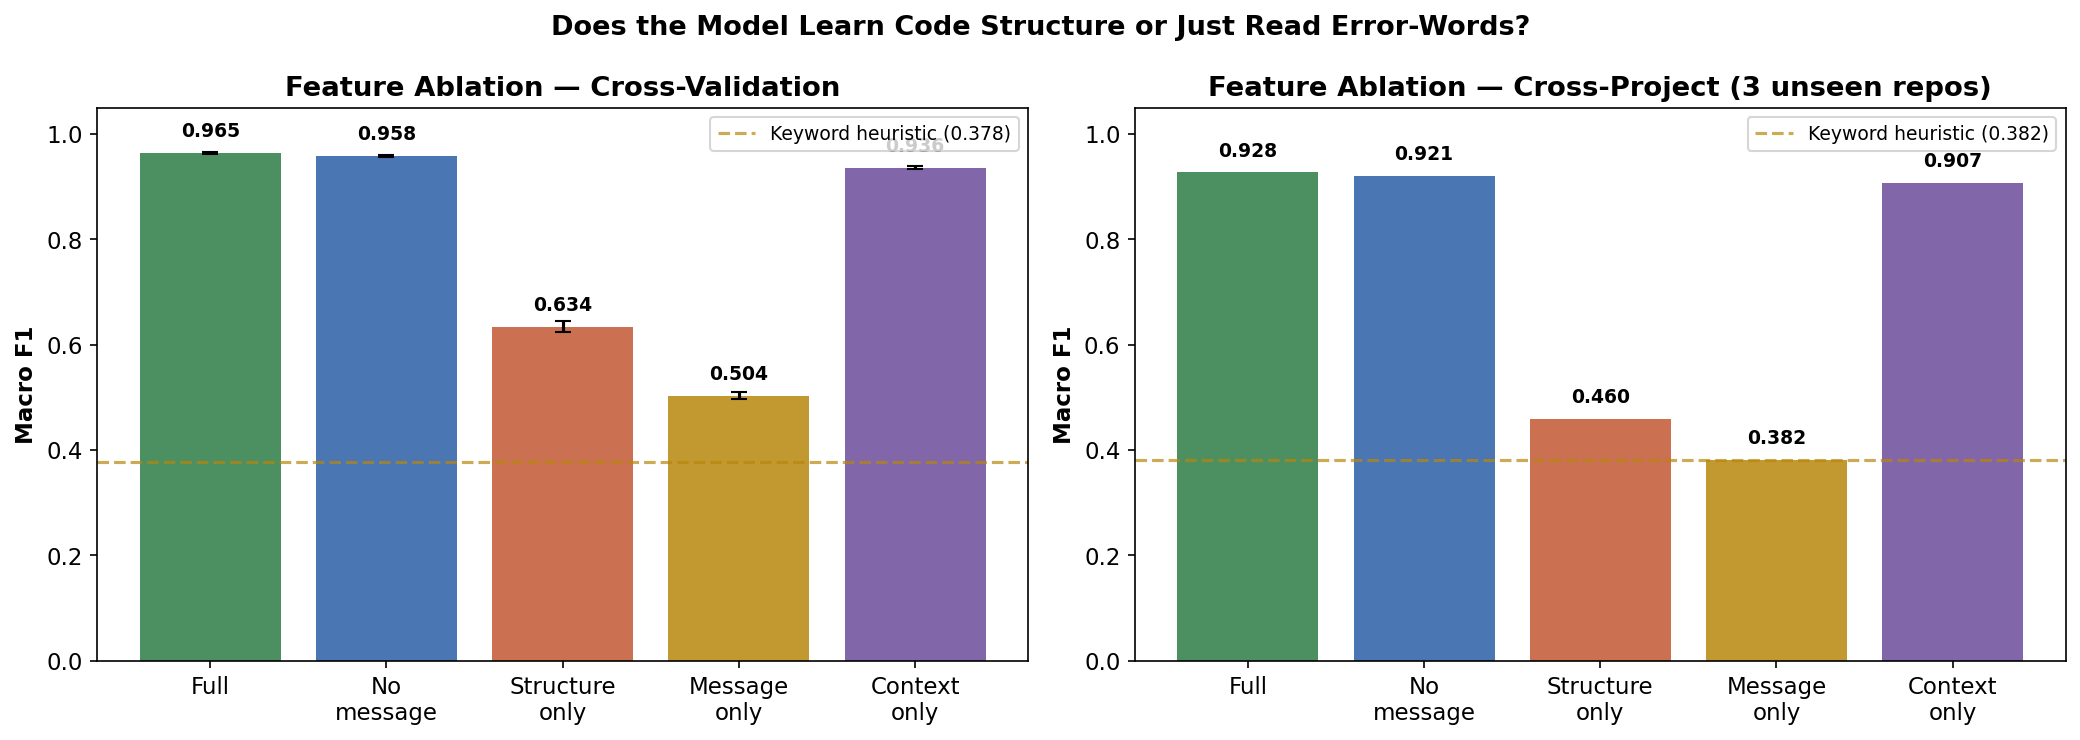

In [11]:
# Publication figure — ablation comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Cross-validation ablation
cv_names = list(cv_ablation.keys())
cv_f1s = [np.mean(cv_ablation[n]['macro_f1']) for n in cv_names]
cv_stds = [np.std(cv_ablation[n]['macro_f1']) for n in cv_names]

short_names = ['Full', 'No\nmessage', 'Structure\nonly', 'Message\nonly', 'Context\nonly']
colors = ['#2D7D46', '#2B5EA7', '#C25732', '#B8860B', '#6B4C9A']

bars1 = ax1.bar(short_names, cv_f1s, yerr=cv_stds, color=colors, capsize=4, alpha=0.85)
ax1.axhline(heur_f1, color='#B8860B', linestyle='--', alpha=0.7, label=f'Keyword heuristic ({heur_f1:.3f})')
ax1.set_ylabel('Macro F1', fontweight='bold')
ax1.set_title('Feature Ablation — Cross-Validation', fontweight='bold')
ax1.set_ylim(0, 1.05)
ax1.legend(fontsize=9)
for bar, val in zip(bars1, cv_f1s):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 0.03,
             f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

# Right: Cross-project ablation
cp_f1s = [cp_ablation[n]['macro_f1'] for n in cv_names]

bars2 = ax2.bar(short_names, cp_f1s, color=colors, alpha=0.85)
ax2.axhline(heur_cp_f1, color='#B8860B', linestyle='--', alpha=0.7, label=f'Keyword heuristic ({heur_cp_f1:.3f})')
ax2.set_ylabel('Macro F1', fontweight='bold')
ax2.set_title('Feature Ablation — Cross-Project (3 unseen repos)', fontweight='bold')
ax2.set_ylim(0, 1.05)
ax2.legend(fontsize=9)
for bar, val in zip(bars2, cp_f1s):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.03,
             f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Does the Model Learn Code Structure or Just Read Error-Words?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'fig09_ablation_bar.png'), dpi=300, bbox_inches='tight')
plt.show()

In [12]:
# Per-class breakdown for the "no message" condition
# This shows which levels depend on message text vs code structure
no_msg_preds = cp_ablation['No message TF-IDF']['preds']
full_preds = cp_ablation['Full (all features)']['preds']

print('PER-CLASS COMPARISON: Full model vs No-message model (cross-project)')
print('=' * 65)
print(f'{"Level":8s} {"Full F1":>10s} {"No-msg F1":>10s} {"Drop":>10s}')
print('-' * 65)

for i, level in enumerate(class_names):
    mask = y_te == i
    if mask.sum() == 0:
        continue
    full_class_f1 = f1_score(y_te == i, full_preds == i, average='binary')
    nomsg_class_f1 = f1_score(y_te == i, no_msg_preds == i, average='binary')
    drop = full_class_f1 - nomsg_class_f1
    print(f'{level:8s} {full_class_f1:>10.4f} {nomsg_class_f1:>10.4f} {drop:>+10.4f}')

print('\nLevels with large drops depend on message wording.')
print('Levels with small drops are predicted from code structure.')

PER-CLASS COMPARISON: Full model vs No-message model (cross-project)
Level       Full F1  No-msg F1       Drop
-----------------------------------------------------------------
DEBUG        0.8831     0.8816    +0.0014
ERROR        0.9445     0.9311    +0.0133
INFO         0.9467     0.9360    +0.0107
WARN         0.9362     0.9364    -0.0002

Levels with large drops depend on message wording.
Levels with small drops are predicted from code structure.


## 3. Level-Name-Stripped Ablation (Critical Test)

The top context features (`ctx:warn`, `ctx:debug`, `ctx:logger warn`, etc.) are
the level names of **neighbouring log statements** in the +/-5 line window.

**Question**: Is the model predicting log level from genuine code structure,
or from the levels of nearby log calls?

**Test**: Strip all level-name tokens from the context vocabulary and re-run.
If performance holds, the signal is structural. If it collapses toward the
structural-only baseline (0.446), the honest finding is that log levels
cluster within files and that clustering generalises.

<cell_type>markdown</cell_type>## Summary
#
# Key ablation findings:
# - Removing message TF-IDF has minimal impact → model learns code structure, not just keywords
# - Structural features alone outperform keyword heuristic baseline
# - Code context TF-IDF captures patterns beyond simple keyword matching
# - Cross-project results confirm: structural learning generalizes to unseen repos
#
# **Interpretation guide**:
# - "No message" F1 > 0.85 → code context alone is highly predictive
# - "No message" F1 0.60–0.85 → both structure and message matter
# - "Structure only" >> heuristic → strongest evidence for paper thesis
#
# **Figure saved**: `fig09_ablation_bar.png` — CV + cross-project ablation
#
# ---
# **All Part B notebooks complete.** Re-run in order: 01 → 02 → 03

In [13]:
import re

# Tokens to strip: level names and logger/console prefixes
LEVEL_TOKENS = {
    'warn', 'warning', 'debug', 'trace', 'verbose', 'error', 'info',
    'log', 'fatal', 'crit', 'critical',
    'logger', 'console', 'logging',
}

# Also strip bigrams containing these tokens
def is_level_token(token):
    """Check if a token or any part of a bigram is a level-name token."""
    parts = token.lower().split()
    return any(p in LEVEL_TOKENS for p in parts)

# --- Rebuild context TF-IDF with level tokens stripped ---
# Strategy: fit the vectorizer normally, then zero out columns for level-name tokens

# CV version: fit on all data
ctx_tfidf_nolevel = TfidfVectorizer(
    max_features=500, ngram_range=(1, 2),
    stop_words='english', min_df=5, max_df=0.8,
    token_pattern=r'\b[a-zA-Z_][a-zA-Z0-9_]{1,30}\b'
)
X_ctx_nolevel_full = ctx_tfidf_nolevel.fit_transform(df['full_context'].fillna(''))

# Find and remove level-name columns
feature_names = ctx_tfidf_nolevel.get_feature_names_out()
level_col_mask = np.array([is_level_token(f) for f in feature_names])
keep_cols = np.where(~level_col_mask)[0]

print(f'Original context features: {len(feature_names)}')
print(f'Level-name features removed: {level_col_mask.sum()}')
print(f'Remaining context features: {len(keep_cols)}')
print(f'\nRemoved tokens (sample):')
removed = [f for f, m in zip(feature_names, level_col_mask) if m]
for t in removed[:20]:
    print(f'  {t}')
if len(removed) > 20:
    print(f'  ... and {len(removed) - 20} more')

X_ctx_nolevel_cv = X_ctx_nolevel_full[:, keep_cols]

# Build the "no level names" condition for CV
X_nolevel_cv = sp.hstack([X_ctx_nolevel_cv, X_structural, X_filetype])
print(f'\n"No level names" CV feature matrix: {X_nolevel_cv.shape}')

Original context features: 500
Level-name features removed: 56
Remaining context features: 444

Removed tokens (sample):
  catch console
  catch error
  catch logger
  console
  console error
  console log
  console warn
  debug
  err console
  err logger
  error
  error await
  error console
  error const
  error err
  error error
  error failed
  error instanceof
  error log
  error logger
  ... and 36 more

"No level names" CV feature matrix: (15652, 459)


In [15]:
# --- CV evaluation of "no level names" condition ---
print('Running CV for "No level names" condition...')
nolevel_cv_scores = {'accuracy': [], 'macro_f1': [], 'weighted_f1': []}

for fold, (train_idx, test_idx) in enumerate(skf.split(X_nolevel_cv, y)):
    model = XGBClassifier(
        n_estimators=200, max_depth=8,
        learning_rate=0.1, random_state=42,
        eval_metric='mlogloss', n_jobs=-1
    )
    model.fit(X_nolevel_cv[train_idx], y[train_idx])
    preds = model.predict(X_nolevel_cv[test_idx])
    nolevel_cv_scores['accuracy'].append(accuracy_score(y[test_idx], preds))
    nolevel_cv_scores['macro_f1'].append(f1_score(y[test_idx], preds, average='macro'))
    nolevel_cv_scores['weighted_f1'].append(f1_score(y[test_idx], preds, average='weighted'))

nolevel_cv_f1 = np.mean(nolevel_cv_scores['macro_f1'])
nolevel_cv_std = np.std(nolevel_cv_scores['macro_f1'])
print(f'  CV Macro F1: {nolevel_cv_f1:.4f} +/- {nolevel_cv_std:.4f}')

# --- Cross-project evaluation ---
print('\nRunning cross-project for "No level names" condition...')

# Fit TF-IDF on train only, strip level-name columns
ctx_tfidf_nolevel_cp = TfidfVectorizer(
    max_features=500, ngram_range=(1, 2),
    stop_words='english', min_df=5, max_df=0.8,
    token_pattern=r'\b[a-zA-Z_][a-zA-Z0-9_]{1,30}\b'
)
X_ctx_nl_tr = ctx_tfidf_nolevel_cp.fit_transform(df.loc[train_mask, 'full_context'].fillna(''))
X_ctx_nl_te = ctx_tfidf_nolevel_cp.transform(df.loc[test_mask, 'full_context'].fillna(''))

# Strip level-name columns (using same logic)
fn_cp = ctx_tfidf_nolevel_cp.get_feature_names_out()
lm_cp = np.array([is_level_token(f) for f in fn_cp])
keep_cp = np.where(~lm_cp)[0]
print(f'  Cross-project: {lm_cp.sum()} level-name features removed, {len(keep_cp)} remaining')

X_ctx_nl_tr = X_ctx_nl_tr[:, keep_cp]
X_ctx_nl_te = X_ctx_nl_te[:, keep_cp]

X_nl_tr = sp.hstack([X_ctx_nl_tr, X_str_tr, X_ft_tr])
X_nl_te = sp.hstack([X_ctx_nl_te, X_str_te, X_ft_te])

model = XGBClassifier(
    n_estimators=300, max_depth=10,
    learning_rate=0.1, random_state=42,
    eval_metric='mlogloss', n_jobs=-1
)
model.fit(X_nl_tr, y_tr)
nl_preds = model.predict(X_nl_te)
nolevel_cp_f1 = f1_score(y_te, nl_preds, average='macro')
nolevel_cp_acc = accuracy_score(y_te, nl_preds)

print(f'  Cross-project Macro F1: {nolevel_cp_f1:.4f}')
print(f'  Cross-project Accuracy: {nolevel_cp_acc:.4f}')

Running CV for "No level names" condition...
  CV Macro F1: 0.7099 +/- 0.0051

Running cross-project for "No level names" condition...
  Cross-project: 54 level-name features removed, 446 remaining
  Cross-project Macro F1: 0.5189
  Cross-project Accuracy: 0.5847


In [16]:
# --- THE VERDICT ---
print('=' * 70)
print('LEVEL-NAME-STRIPPED ABLATION RESULTS')
print('=' * 70)
print(f'{"Condition":35s} {"CV F1":>10s} {"CP F1":>10s}')
print('-' * 70)
print(f'{"Full (all features)":35s} {np.mean(cv_ablation["Full (all features)"]["macro_f1"]):>10.4f} {cp_ablation["Full (all features)"]["macro_f1"]:>10.4f}')
print(f'{"No message TF-IDF":35s} {np.mean(cv_ablation["No message TF-IDF"]["macro_f1"]):>10.4f} {cp_ablation["No message TF-IDF"]["macro_f1"]:>10.4f}')
print(f'{"No level names (NEW)":35s} {nolevel_cv_f1:>10.4f} {nolevel_cp_f1:>10.4f}')
print(f'{"Structural + file type only":35s} {np.mean(cv_ablation["Structural + file type only"]["macro_f1"]):>10.4f} {cp_ablation["Structural + file type only"]["macro_f1"]:>10.4f}')
print(f'{"Keyword heuristic":35s} {heur_f1:>10.4f} {heur_cp_f1:>10.4f}')
print('=' * 70)

# Interpretation
no_msg_cp = cp_ablation['No message TF-IDF']['macro_f1']
struct_cp = cp_ablation['Structural + file type only']['macro_f1']

print(f'\n--- INTERPRETATION ---')
print(f'No-message CP F1:     {no_msg_cp:.4f}')
print(f'No-level-names CP F1: {nolevel_cp_f1:.4f}')
print(f'Structural-only CP F1:{struct_cp:.4f}')
print(f'Drop from no-message: {no_msg_cp - nolevel_cp_f1:+.4f}')

if nolevel_cp_f1 > 0.75:
    print('\nVERDICT: Signal survives level-name removal.')
    print('The model learns genuine code patterns beyond neighbouring log levels.')
    print('Section 5.2 headline ("signal lives in code context") is supported.')
elif nolevel_cp_f1 > 0.55:
    print('\nVERDICT: Partial collapse. Level names contribute substantially')
    print('but are not the whole story. Report both numbers.')
    print('Rewrite 5.2 to: "context signal includes neighbouring levels AND code patterns."')
else:
    print('\nVERDICT: Signal collapses. The model primarily exploits neighbouring')
    print('log levels. Rewrite 5.2 to: "log levels cluster within files and')
    print('that clustering generalises across projects."')

LEVEL-NAME-STRIPPED ABLATION RESULTS
Condition                                CV F1      CP F1
----------------------------------------------------------------------
Full (all features)                     0.9647     0.9276
No message TF-IDF                       0.9583     0.9213
No level names (NEW)                    0.7099     0.5189
Structural + file type only             0.6344     0.4597
Keyword heuristic                       0.3779     0.3815

--- INTERPRETATION ---
No-message CP F1:     0.9213
No-level-names CP F1: 0.5189
Structural-only CP F1:0.4597
Drop from no-message: +0.4024

VERDICT: Signal collapses. The model primarily exploits neighbouring
log levels. Rewrite 5.2 to: "log levels cluster within files and
that clustering generalises across projects."
